In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

## Feature Engineering part

In [29]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [30]:
print(df.isnull().sum())
print(f"Duplicates: {df.duplicated().sum()}")

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicates: 0


In [31]:
bool_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[bool_cols] = df[bool_cols].replace({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [32]:
df['area'] = np.sqrt(df['area'])

scaler = StandardScaler()
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,1.106739,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,True,False,False
1,12250000,1.703091,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,True,False,False
2,12250000,2.063130,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,False,True,False
3,12215000,1.139163,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,True,False,False
4,11410000,1.106739,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,True,False,False


## Supervised Learning

In [33]:
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"Linear Regression R2: {r2_score(y_test, lr.predict(X_test)):.4f}")

Linear Regression R2: 0.6524


In [35]:
lasso = Lasso(alpha=0.9)
lasso.fit(X_train, y_train)
print(f"Lasso Regression R2: {r2_score(y_test, lasso.predict(X_test)):.4f}")

Lasso Regression R2: 0.6524


In [36]:
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_gs = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='r2', n_jobs=-1)
dt_gs.fit(X_train, y_train)
print(f"Decision Tree Best Params: {dt_gs.best_params_}")
print(f"Decision Tree CV R2: {dt_gs.best_score_:.4f}")
print(f"Decision Tree Test R2: {r2_score(y_test, dt_gs.best_estimator_.predict(X_test)):.4f}")

Decision Tree Best Params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree CV R2: 0.5270
Decision Tree Test R2: 0.4861


In [37]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_gs.fit(X_train, y_train)
print(f"Random Forest Best Params: {rf_gs.best_params_}")
print(f"Random Forest CV R2: {rf_gs.best_score_:.4f}")
print(f"Random Forest Test R2: {r2_score(y_test, rf_gs.best_estimator_.predict(X_test)):.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest CV R2: 0.6374
Random Forest Test R2: 0.6131


## Unsupervised Learning

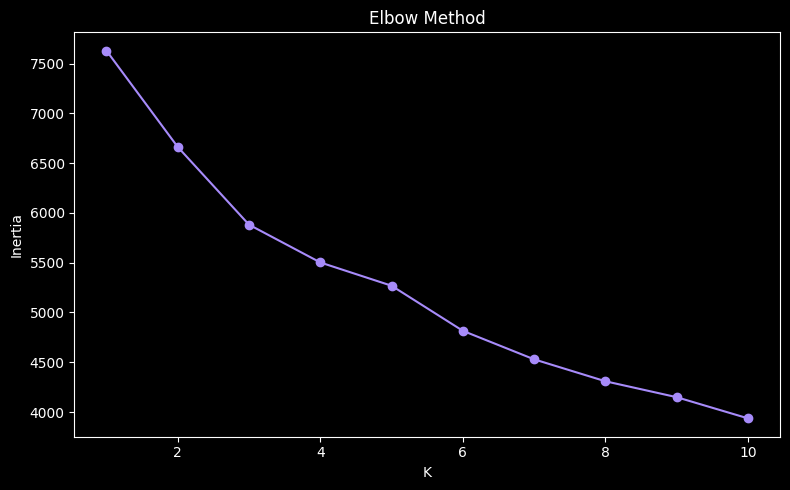

In [38]:
X_scaled = StandardScaler().fit_transform(df.drop(columns=['price']))

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.style.use('dark_background')
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, 'o-', color='#a78bfa')
plt.xlabel('K', color='white')
plt.ylabel('Inertia', color='white')
plt.title('Elbow Method', color='white')
plt.tight_layout()
plt.show()

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
df_vis = df.copy()
df_vis['Cluster'] = cluster_labels
print(df_vis['Cluster'].value_counts())

Cluster
0    227
1    178
2    140
Name: count, dtype: int64


Explained Variance Ratio: [0.18560746 0.11654313]
Total Variance Retained: 0.3022


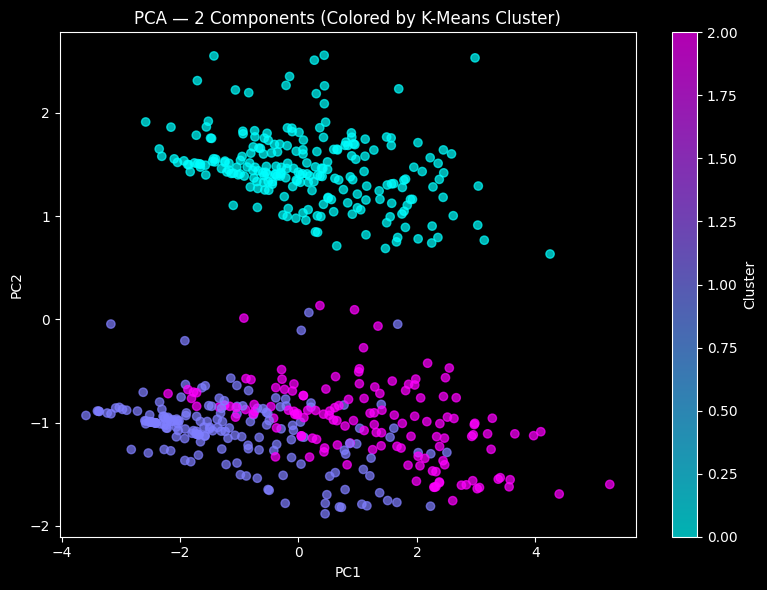

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Retained: {pca.explained_variance_ratio_.sum():.4f}")

plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='cool', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', color='white')
plt.ylabel('PC2', color='white')
plt.title('PCA — 2 Components (Colored by K-Means Cluster)', color='white')
plt.tight_layout()
plt.show()

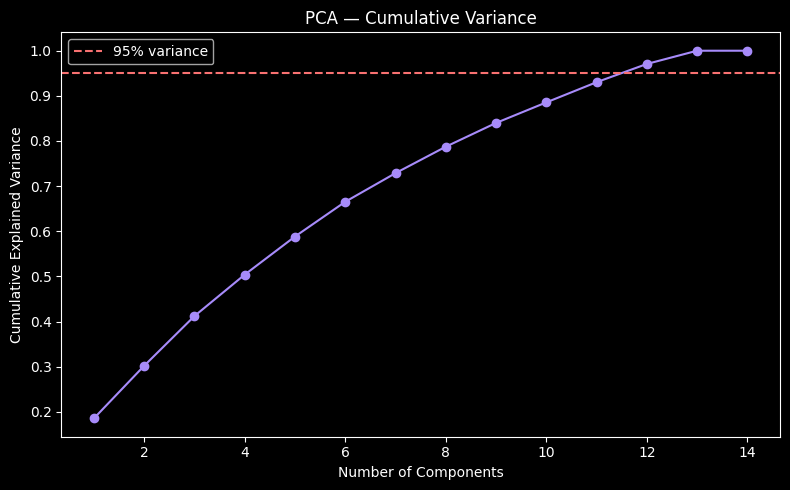

Components needed to retain 95% variance: 12


In [41]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='#a78bfa')
plt.axhline(0.95, color='#f87171', linestyle='--', label='95% variance')
plt.xlabel('Number of Components', color='white')
plt.ylabel('Cumulative Explained Variance', color='white')
plt.title('PCA — Cumulative Variance', color='white')
plt.legend()
plt.tight_layout()
plt.show()

n95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed to retain 95% variance: {n95}")

## XGBoost — Gradient Boosting with Hyperparameter Tuning

In [42]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 2, 5]
}

from sklearn.model_selection import RandomizedSearchCV

xgb_rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_rs.fit(X_train, y_train)

print(f"Best Params: {xgb_rs.best_params_}")
print(f"Best CV R2: {xgb_rs.best_score_:.4f}")
print(f"Test R2: {r2_score(y_test, xgb_rs.best_estimator_.predict(X_test)):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV R2: 0.6343
Test R2: 0.6460


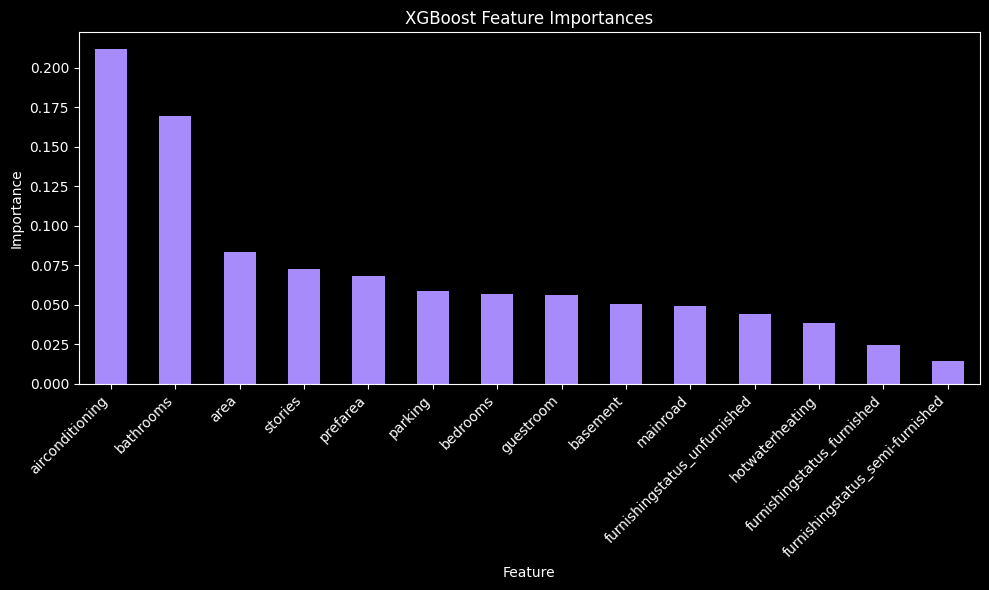

In [43]:
feat_imp = pd.Series(xgb_rs.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='#a78bfa')
plt.title('XGBoost Feature Importances', color='white')
plt.xlabel('Feature', color='white')
plt.ylabel('Importance', color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.tight_layout()
plt.show()

In [44]:
results = {
    'Linear Regression': r2_score(y_test, lr.predict(X_test)),
    'Lasso': r2_score(y_test, lasso.predict(X_test)),
    'Decision Tree': r2_score(y_test, dt_gs.best_estimator_.predict(X_test)),
    'Random Forest': r2_score(y_test, rf_gs.best_estimator_.predict(X_test)),
    'XGBoost': r2_score(y_test, xgb_rs.best_estimator_.predict(X_test))
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Test R2 Score']).sort_values('Test R2 Score', ascending=False)
print(results_df)

                   Test R2 Score
Linear Regression       0.652380
Lasso                   0.652379
XGBoost                 0.646002
Random Forest           0.613075
Decision Tree           0.486054
